# TASS 2018 — Análisis de Sentimientos con Bag-of-Words, N-gramas y Selección de Modelo

**Institución:** Universidad Pedagogica y Tecnológica de colombia
**Referencia:** Jurafsky, D. & Martin, J. H. (2025). *Speech and Language Processing* (3rd ed.), Ch. 4 — Naive Bayes, Text Classification, and Sentiment
**Metodología del proyecto:** CRISP-ML(Q) (Cross-Industry Standard Process for Machine Learning with Quality assurance)
**Compatibilidad Python:** 3.10 · 3.11 · 3.12 · 3.13

**Fabian Andres Rincon - Jhon sebastian Rodriguez**

---

## Mapa CRISP-ML(Q) de este notebook

| Fase CRISP-ML(Q) | Sección del notebook |
|---|---|
| 1. Business and Data Understanding | Secciones 1-2 |
| 2. Data Preparation | Secciones 3-5 |
| 3. Feature Engineering | Secciones 6-7 |
| 4. Model Development | Secciones 8-12 |
| 5. Evaluation | Secciones 13-15 |
| 6. Deployment / Monitoring | Sección 16 |

**Cambios respecto a la versión anterior:**
- Se elimina `VotingClassifier`; todos los modelos se evalúan de forma individual.
- Se da prioridad al manejo del desbalance de clases (`class_weight='balanced'` en todos los modelos compatibles).
- El ajuste de hiperparámetros (`GridSearchCV`) se ejecuta **una sola vez, al final**, únicamente sobre el modelo seleccionado — no al inicio del análisis.
- El *Summary Report* final se calcula también sobre un conjunto de prueba **balanceado** (mismo `support` por clase), además del conjunto de prueba original.
- El notebook se reorganiza explícitamente en las 6 fases de CRISP-ML(Q).
- **Nuevo:** se incorporan las características léxicas de `logic/feature_extraction.py`
  (`FeatureExtraction`, sobre la tokenización de `logic/text_processing.py`) mediante un
  adaptador scikit-learn propio (`LexicalFeaturesTransformer`), y se construyen y comparan tres
  representaciones — BoW/TF-IDF sola, léxica sola y su unión (`FeatureUnion`) — antes de elegir
  el algoritmo de clasificación (secciones 3.3-3.5).
- **Nuevo:** ablación de las seis características léxicas nuevas en grupos de 3, comparación de
  una segunda estrategia de unión (`scipy.sparse.hstack` manual) y comparación con un baseline de
  mayoría y con TASS 2018 (CEUR-WS Vol. 2172), en las secciones 5.4-5.7.


---

# Fase 1: Business and Data Understanding

## 1.1 Objetivo de negocio y criterio de éxito

**Objetivo de negocio:** clasificar automáticamente la polaridad de tuits en español (TASS 2018) en cuatro categorías, como insumo para tareas de monitoreo de opinión (marca, producto, evento).

**Criterio de éxito del modelo:** dado que las clases están desbalanceadas, se usará **F1-macro** como métrica principal de selección y optimización (trata a cada clase por igual), reportando también accuracy, precisión y recall macro.

**Restricciones del proyecto:**
- Conjunto de datos pequeño (~1.500 tuits en total), por lo que se evitarán modelos con muchos parámetros que puedan sobreajustar.
- El texto es de Twitter: informal, con menciones, hashtags, URLs y alargamientos de caracteres ("graciaaaas").
- Los experimentos de búsqueda de hiperparámetros deben mantenerse acotados: primero se explora (vectorización, n-gramas, modelos, balanceo) y el *fine-tuning* costoso se aplica una única vez, al final, sobre el modelo ya seleccionado.

## 1.2 El dataset TASS 2018

TASS es una campaña de evaluación centrada en el análisis de sentimientos en español. La edición 2018 usa datos de Twitter con cuatro etiquetas de polaridad:

| Etiqueta | Significado |
|---|---|
| **P** | Sentimiento positivo |
| **N** | Sentimiento negativo |
| **NEU** | Neutral (sin polaridad positiva ni negativa) |
| **NONE** | Tuit sin carga de sentimiento |


In [34]:
from pathlib import Path
from collections import Counter
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Se busca el archivo tanto en el directorio actual como en ./data/tass,
# para que el notebook funcione sin depender de una ruta absoluta local.
CANDIDATE_DIRS = [
    Path.cwd(),
    Path.cwd().parent / 'data' / 'tass'
]

DIR_DATA = next(
    (d for d in CANDIDATE_DIRS if (d / 'tass2018_es_train.csv').exists()),
    CANDIDATE_DIRS[-1]
)

print(f'Data directory: {DIR_DATA}')


Data directory: c:\Users\fabia\OneDrive\Documentos\classical-text-representation\data\tass


## 1.3 Carga de los conjuntos de entrenamiento y prueba


In [35]:
data_train = pd.read_csv(DIR_DATA /'tass2018_es_train.csv', sep=',')
data_test = pd.read_csv(DIR_DATA / 'tass2018_es_test.csv', sep=',')

print(f'Muestras de entrenamiento: {len(data_train):,}')
print(f'Muestras de prueba:        {len(data_test):,}')
print(f'\nColumnas: {data_train.columns.tolist()}')
data_train.head(3)


Muestras de entrenamiento: 1,008
Muestras de prueba:        506

Columnas: ['tweetid', 'user', 'content', 'date', 'lang', 'sentiment/polarity/value']


,tweetid,user,content,date,lang,sentiment/polarity/value
0,768213876278165504,OnceBukowski,-Me caes muy bien \r\n-Tienes que jugar más pa...,2016-08-23 22:30:35,es,NONE
1,768213567418036224,anahorxn,@myendlesshazza a. que puto mal escribo\r\n\r\...,2016-08-23 22:29:21,es,N
2,768212591105703936,martitarey13,@estherct209 jajajaja la tuya y la d mucha gen...,2016-08-23 22:25:29,es,N


---

# Fase 2: Data Preparation

## 2.1 Análisis exploratorio de los datos (EDA)

Antes de limpiar y vectorizar se revisan valores faltantes, duplicados, longitud de los tuits y la distribución de clases, ya que el desbalance detectado aquí determina las decisiones de balanceo de las fases siguientes.


In [36]:
print('Valores nulos por columna (train):')
print(data_train.isnull().sum())
print(f'\nFilas duplicadas (train): {data_train.duplicated().sum()}')
print(f'Tuits duplicados por contenido (train): {data_train["content"].duplicated().sum()}')

data_train['text_length'] = data_train['content'].str.split().apply(len)
print('\nEstadísticas de longitud del tuit (en tokens, train):')
print(data_train['text_length'].describe())


Valores nulos por columna (train):
tweetid                     0
user                        0
content                     0
date                        0
lang                        0
sentiment/polarity/value    0
dtype: int64

Filas duplicadas (train): 0
Tuits duplicados por contenido (train): 0

Estadísticas de longitud del tuit (en tokens, train):
count    1008.000000
mean       15.373016
std         5.804986
min         5.000000
25%        11.000000
50%        15.000000
75%        20.000000
max        30.000000
Name: text_length, dtype: float64


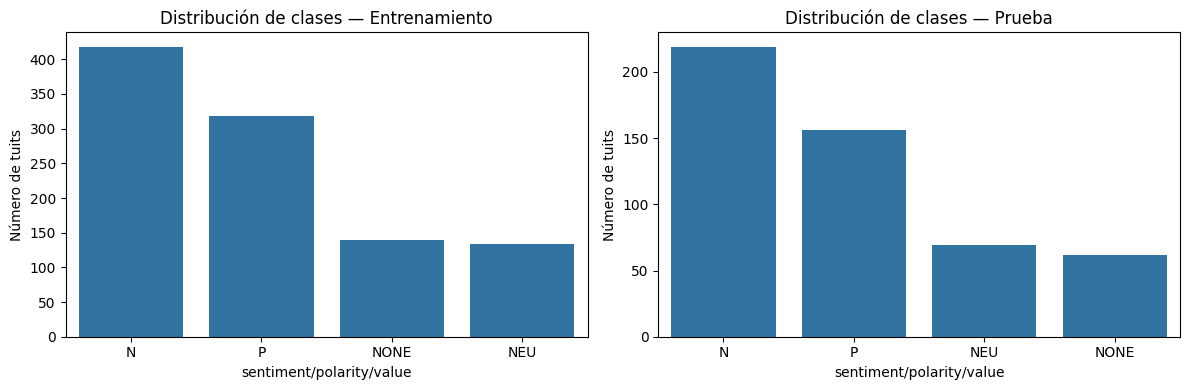

Entrenamiento: {'N': 418, 'P': 318, 'NONE': 139, 'NEU': 133}
Prueba:        {'N': 219, 'P': 156, 'NEU': 69, 'NONE': 62}

Ambos conjuntos están desbalanceados (N y P dominan sobre NEU y NONE); esto motiva el uso de class_weight='balanced' y la creación de un conjunto de prueba balanceado para la evaluación final (Fase 5).


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_counts = data_train['sentiment/polarity/value'].value_counts()
test_counts = data_test['sentiment/polarity/value'].value_counts()

sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0])
axes[0].set_title('Distribución de clases — Entrenamiento')
axes[0].set_ylabel('Número de tuits')

sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1])
axes[1].set_title('Distribución de clases — Prueba')
axes[1].set_ylabel('Número de tuits')

plt.tight_layout()
plt.show()

print('Entrenamiento:', train_counts.to_dict())
print('Prueba:       ', test_counts.to_dict())
print('\nAmbos conjuntos están desbalanceados (N y P dominan sobre NEU y NONE); '
      'esto motiva el uso de class_weight=\'balanced\' y la creación de un conjunto '
      'de prueba balanceado para la evaluación final (Fase 5).')


## 2.2 Limpieza de texto para tuits en español

Se sustituye la normalización mínima (`str.lower()`) por una limpieza específica para tuits en español: URLs, menciones, hashtags y alargamientos de caracteres, conservando además emoticonos/emojis comunes como marcadores de polaridad y marcando explícitamente el alcance de la negación antes de vectorizar.


In [38]:
POSITIVE_EMOTICONS = [':)', ':-)', ':d', ':-d', '=)', ';)', ';-)', ':3', 'xd', '(:', '(=']
NEGATIVE_EMOTICONS = [':(', ':-(', '=(', ":'(", ":'-(", '):', '-_-', ':/', ':-/']

POSITIVE_EMOJIS = set('😀😃😄😁😆😊🙂😉'
                       '😍🥰😘😻👍👏🎉❤️'
                       '💕💖✨🔥👌😂🙌💪')
NEGATIVE_EMOJIS = set('😢😭😞😔😡😠💔👎'
                       '🤬😒😩😫🙁😣😤👿'
                       '💀')


def replace_emoticons_emojis(text: str) -> str:
    """Sustituye emoticonos y emojis comunes por marcadores de polaridad."""
    text = str(text).lower()
    for token in POSITIVE_EMOTICONS:
        text = text.replace(token, ' emojipos ')
    for token in NEGATIVE_EMOTICONS:
        text = text.replace(token, ' emojineg ')

    chars = []
    for ch in text:
        if ch in POSITIVE_EMOJIS:
            chars.append(' emojipos ')
        elif ch in NEGATIVE_EMOJIS:
            chars.append(' emojineg ')
        else:
            chars.append(ch)
    return ''.join(chars)


def clean_tweet(text: str) -> str:
    """Normaliza un tuit en español para su vectorización."""
    text = replace_emoticons_emojis(text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)          # URLs
    text = re.sub(r'@\w+', ' ', text)                            # menciones
    text = re.sub(r'#(\w+)', r'\1', text)                        # hashtags -> palabra
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)                   # alargamientos (aaaa -> aa)
    text = re.sub(r'[^a-záéíóúñü¿?¡!\s]', ' ', text)             # solo letras/¿?¡!
    text = re.sub(r'\s+', ' ', text).strip()                     # espacios múltiples
    return text


NEGATION_CUES = {'no', 'nunca', 'jamás', 'jamas', 'ni', 'tampoco'}
NEGATION_STOPPERS = {'pero', 'sino', 'aunque'}


def mark_negation(text: str, window: int = 4) -> str:
    """Antepone `no_` a las palabras dentro del alcance de una negación."""
    tokens = text.split()
    output = []
    scope_remaining = 0
    for tok in tokens:
        if tok in NEGATION_CUES:
            output.append(tok)
            scope_remaining = window
            continue
        if tok in NEGATION_STOPPERS:
            scope_remaining = 0
            output.append(tok)
            continue
        if scope_remaining > 0:
            output.append(f'no_{tok}')
            scope_remaining -= 1
        else:
            output.append(tok)
    return ' '.join(output)


# Ejemplo de transformación
for sample in data_train['content'].head(2):
    print('ANTES   :', sample.replace(chr(10), ' '))
    print('LIMPIO  :', clean_tweet(sample))
    print('NEGACION:', mark_negation(clean_tweet(sample)))
    print()

print('Ejemplo adicional -- emojis, emoticonos y negacion:')
demo = 'No me gusta nada esto :( pero el servicio estuvo genial 😍'
print('ANTES   :', demo)
print('LIMPIO  :', clean_tweet(demo))
print('NEGACION:', mark_negation(clean_tweet(demo)))


 -Haber si me muero, deja de ser otako con Russel y conmigo
LIMPIO  : me caes muy bien tienes que jugar más partidas al lol con russel y conmigo por qué tan otako deja de ser otako haber si me muero
NEGACION: me caes muy bien tienes que jugar más partidas al lol con russel y conmigo por qué tan otako deja de ser otako haber si me muero

 3. ha quedado raro el "cómetelo" ahí JAJAJAJAibo
LIMPIO  : a que puto mal escribo b me sigo surrando help ha quedado raro el cómetelo ahí jajajaja
NEGACION: a que puto mal escribo b me sigo surrando help ha quedado raro el cómetelo ahí jajajaja

Ejemplo adicional -- emojis, emoticonos y negacion:
ANTES   : No me gusta nada esto :( pero el servicio estuvo genial 😍
LIMPIO  : no me gusta nada esto emojineg pero el servicio estuvo genial emojipos
NEGACION: no no_me no_gusta no_nada no_esto emojineg pero el servicio estuvo genial emojipos


## 2.3 Preprocesamiento completo y codificación de etiquetas


In [39]:
def preprocess_tweet(text: str) -> str:
    """Limpieza completa: normalizacion de tuit + marcado del alcance de la negacion."""
    return mark_negation(clean_tweet(text))


le = LabelEncoder()

x_train_text = data_train['content'].apply(preprocess_tweet).tolist()
y_train = le.fit_transform(data_train['sentiment/polarity/value'])

x_test_text = data_test['content'].apply(preprocess_tweet).tolist()
y_test = le.transform(data_test['sentiment/polarity/value'])

print(f'Clases: {le.classes_.tolist()}')
print(f'Distribucion de clases (train, codificada): {sorted(Counter(y_train).items())}')
print(f'Distribucion de clases (test, codificada):  {sorted(Counter(y_test).items())}')

empty_after_cleaning = sum(1 for t in x_train_text if len(t) == 0)
print(f'Tuits vacios tras la limpieza: {empty_after_cleaning}')


Clases: ['N', 'NEU', 'NONE', 'P']
Distribucion de clases (train, codificada): [(np.int64(0), 418), (np.int64(1), 133), (np.int64(2), 139), (np.int64(3), 318)]
Distribucion de clases (test, codificada):  [(np.int64(0), 219), (np.int64(1), 69), (np.int64(2), 62), (np.int64(3), 156)]
Tuits vacios tras la limpieza: 0


---

# Fase 3: Feature Engineering

## 3.1 Estrategia de validación

Se usa `StratifiedKFold` en lugar de `ShuffleSplit` para respetar la proporción de clases en cada partición, algo especialmente importante dado el desbalance detectado en la Fase 2.

Además, se define un conjunto de *scorers* (`SCORING`) con `zero_division=0` explícito para `f1_macro`, `precision_macro` y `recall_macro`: en folds pequeños es posible que una clase minoritaria (NEU/NONE) se quede sin ninguna muestra predicha, y sin este ajuste `cross_validate`/`GridSearchCV` emiten un `UndefinedMetricWarning` por cada fold y métrica afectada.


In [40]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(cv_strategy)

# Scorers explicitos con zero_division=0: en folds pequeños es posible que una clase
# minoritaria (NEU/NONE) se quede sin ninguna muestra predicha; sin este ajuste,
# sklearn emite un UndefinedMetricWarning por cada fold y metrica afectada.
from sklearn.metrics import make_scorer

SCORING = {
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
    'accuracy': 'accuracy',
    'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
    'recall_macro': make_scorer(recall_score, average='macro', zero_division=0),
}


StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 3.2 N-gramas: comparación de vectorizadores

Se mantiene el uso de N-gramas y se evalúa su impacto real sobre el desempeño: en lugar de fijar `ngram_range=(1, 3)` sin justificación, se comparan por validación cruzada distintas combinaciones de vectorizador (Count/TF-IDF), unidad de análisis (palabra/carácter) y rango de n-gramas, usando un clasificador base con `class_weight='balanced'` para no favorecer a las clases mayoritarias en esta selección.


In [41]:
baseline_clf = LogisticRegression(solver='lbfgs', C=10, max_iter=2000, class_weight='balanced')

vectorizer_grid = {
    'Count uni':         CountVectorizer(ngram_range=(1, 1), min_df=2),
    'Count uni+bi':       CountVectorizer(ngram_range=(1, 2), min_df=2),
    'Count uni+bi+tri':   CountVectorizer(ngram_range=(1, 3), min_df=2),
    'TFIDF uni':         TfidfVectorizer(ngram_range=(1, 1), min_df=2),
    'TFIDF uni+bi':       TfidfVectorizer(ngram_range=(1, 2), min_df=2),
    'TFIDF uni+bi+tri':   TfidfVectorizer(ngram_range=(1, 3), min_df=2),
    'Count char(3-5)':    CountVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2),
    'TFIDF char(3-5)':    TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2),
}

vectorizer_results = []
for vec_name, vectorizer in vectorizer_grid.items():
    pipe = Pipeline([('vect', vectorizer), ('clf', baseline_clf)])
    scores = cross_validate(
        pipe, x_train_text, y_train, cv=cv_strategy,
        scoring={'f1_macro': SCORING['f1_macro'], 'accuracy': SCORING['accuracy']},
    )
    vectorizer_results.append({
        'vectorizer': vec_name,
        'f1_macro': scores['test_f1_macro'].mean(),
        'accuracy': scores['test_accuracy'].mean(),
    })

vectorizer_results_df = pd.DataFrame(vectorizer_results).sort_values('f1_macro', ascending=False)
vectorizer_results_df


,vectorizer,f1_macro,accuracy
7,TFIDF char(3-5),0.408682,0.513871
6,Count char(3-5),0.405375,0.496995
3,TFIDF uni,0.391143,0.464283
0,Count uni,0.384161,0.456332
1,Count uni+bi,0.381616,0.468233
4,TFIDF uni+bi,0.376054,0.460312
5,TFIDF uni+bi+tri,0.375180,0.463268
2,Count uni+bi+tri,0.370838,0.461253


In [42]:
best_vectorizer_name = vectorizer_results_df.iloc[0]['vectorizer']
best_vectorizer = vectorizer_grid[best_vectorizer_name]
print(f'Vectorizador seleccionado (mejor F1-macro en CV): {best_vectorizer_name}')


Vectorizador seleccionado (mejor F1-macro en CV): TFIDF char(3-5)


## 3.3 Características léxicas (`logic.feature_extraction`) y adaptador scikit-learn

Además de BoW/TF-IDF se incorpora un segundo tipo de representación: características léxicas
calculadas por `FeatureExtraction` (`logic/feature_extraction.py`), que a su vez usa la
tokenización de `TextProcessing` (`logic/text_processing.py`, `TweetTokenizer` de NLTK) y el
diccionario léxico en español (`logic/lexical_features.py`). Este vector incluye, entre otras,
posición ponderada de palabras, diversidad léxica, pronombres por persona, adverbios,
adjetivos con carga positiva/negativa, marcadores de "quién" (general/masculino/femenino) y las
seis características nuevas ya implementadas: `reaction_words`, `support_words`,
`apology_words`, `recommendation_words`, `preference_words`, `experience_words`.

`FeatureExtraction.get_features_lexical` procesa **un tuit a la vez** (no por lotes), así que se
construye un adaptador `LexicalFeaturesTransformer` con interfaz `fit`/`transform` compatible con
scikit-learn (`BaseEstimator`, `TransformerMixin`) que itera el corpus y apila los vectores. Se le
da como entrada el **mismo texto preprocesado** (`preprocess_tweet`, sección 2.3) que recibe el
vectorizador BoW/TF-IDF, para que las tres representaciones de la Fase 2 (BoW sola, léxica sola,
unión) compartan exactamente el mismo pipeline de limpieza — tal como pide el enunciado — en vez
de mezclar dos preprocesamientos distintos para el mismo tuit.


In [43]:
import sys
from sklearn.base import BaseEstimator, TransformerMixin

# logic/ vive junto a notebooks/ en la raíz del proyecto; se busca igual que DIR_DATA,
# sin depender de una ruta absoluta local.
LOGIC_CANDIDATE_DIRS = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
LOGIC_DIR = next((d for d in LOGIC_CANDIDATE_DIRS if (d / 'logic' / 'feature_extraction.py').exists()),
                  Path.cwd().parent)
if str(LOGIC_DIR) not in sys.path:
    sys.path.insert(0, str(LOGIC_DIR))

from logic.feature_extraction import FeatureExtraction
from logic.text_processing import TextProcessing

# Nombres, en orden, de las entradas que produce FeatureExtraction.get_features_lexical
# (deben coincidir exactamente con el orden en que `vector` se construye en feature_extraction.py).
LEXICAL_FEATURE_NAMES = [
    'weighted_position', 'weighted_normalized',
    'label_mention', 'label_url', 'label_hashtag', 'label_emoji', 'label_retweets',
    'lexical_diversity', 'label_word',
    'first_person_singular', 'second_person_singular', 'third_person_singular',
    'first_person_plurar', 'second_person_plurar', 'third_person_plurar',
    'avg_word', 'kur_word', 'skew_word',
    'adverb_neg', 'adverb_time', 'adverb_place', 'adverb_mode', 'adverb_cant', 'adverb_all',
    'adjetives_neg', 'adjetives_pos',
    'who_general', 'who_male', 'who_female',
    'reaction_words', 'support_words', 'apology_words',
    'recommendation_words', 'preference_words', 'experience_words',
]
# Las 6 features "nuevas" que pide la Fase 4 para la ablación en grupos de 3.
NEW_LEXICAL_FEATURES = LEXICAL_FEATURE_NAMES[-6:]
print(f'Total de features léxicas: {len(LEXICAL_FEATURE_NAMES)} (incluye {len(NEW_LEXICAL_FEATURES)} nuevas: {NEW_LEXICAL_FEATURES})')

# Verificación rápida de que la tokenización de FeatureExtraction (TweetTokenizer, igual que
# TextProcessing.tokenizer) separa razonablemente un tuit ya preprocesado.
_demo_tweet = x_train_text[0]
print('\nEjemplo de tokenización (TextProcessing.tokenizer / TweetTokenizer):')
print(TextProcessing.tokenizer(_demo_tweet))


class LexicalFeaturesTransformer(BaseEstimator, TransformerMixin):
    """Adaptador scikit-learn (fit/transform) sobre `FeatureExtraction.get_features_lexical`.

    `FeatureExtraction` calcula un vector determinista por tuit (conteos y estadísticas sobre
    los tokens del propio tuit): no hay ningún parámetro que deba *aprenderse* del corpus de
    entrenamiento, por lo que `fit` es un no-op. Se conserva el método, en vez de omitirlo, por
    dos razones: (1) mantiene la interfaz fit/transform exigida por `Pipeline`/`FeatureUnion`, y
    (2) deja explícito el contrato de que, si en el futuro se agrega algún componente entrenable
    (p. ej. una normalización interna), debería ajustarse únicamente con datos de entrenamiento,
    igual que el resto de transformadores de este notebook.

    `exclude_features` permite eliminar columnas por nombre (se usa en la Fase 4 para la
    ablación de las nuevas características en grupos de 3).
    """

    def __init__(self, lang='es', exclude_features=None):
        self.lang = lang
        self.exclude_features = exclude_features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        extractor = FeatureExtraction(lang=self.lang)
        n_feats = len(LEXICAL_FEATURE_NAMES)
        rows = []
        for text in X:
            vec = extractor.get_features_lexical(text if text else ' ')
            if vec is None or len(vec) != n_feats:
                vec = np.zeros(n_feats)
            rows.append(vec)
        matrix = np.nan_to_num(np.asarray(rows, dtype=np.float64))
        keep_idx = self._keep_idx()
        return matrix[:, keep_idx]

    def _keep_idx(self):
        excluded = set(self.exclude_features) if self.exclude_features else set()
        return [i for i, name in enumerate(LEXICAL_FEATURE_NAMES) if name not in excluded]

    def get_feature_names_out(self, input_features=None):
        keep_idx = self._keep_idx()
        return np.array([LEXICAL_FEATURE_NAMES[i] for i in keep_idx])


Total de features léxicas: 35 (incluye 6 nuevas: ['reaction_words', 'support_words', 'apology_words', 'recommendation_words', 'preference_words', 'experience_words'])

Ejemplo de tokenización (TextProcessing.tokenizer / TweetTokenizer):
['me', 'caes', 'muy', 'bien', 'tienes', 'que', 'jugar', 'más', 'partidas', 'al', 'lol', 'con', 'russel', 'y', 'conmigo', 'por', 'qué', 'tan', 'otako', 'deja', 'de', 'ser', 'otako', 'haber', 'si', 'me', 'muero']


In [61]:
print("Número de nombres definidos:", len(LEXICAL_FEATURE_NAMES))

print("\nCaracterísticas léxicas utilizadas:")
for i, feature_name in enumerate(LEXICAL_FEATURE_NAMES, start=1):
    print(f"{i:02d}. {feature_name}")

Número de nombres definidos: 35

Características léxicas utilizadas:
01. weighted_position
02. weighted_normalized
03. label_mention
04. label_url
05. label_hashtag
06. label_emoji
07. label_retweets
08. lexical_diversity
09. label_word
10. first_person_singular
11. second_person_singular
12. third_person_singular
13. first_person_plurar
14. second_person_plurar
15. third_person_plurar
16. avg_word
17. kur_word
18. skew_word
19. adverb_neg
20. adverb_time
21. adverb_place
22. adverb_mode
23. adverb_cant
24. adverb_all
25. adjetives_neg
26. adjetives_pos
27. who_general
28. who_male
29. who_female
30. reaction_words
31. support_words
32. apology_words
33. recommendation_words
34. preference_words
35. experience_words


### Escalado de las características léxicas

El vector léxico mezcla escalas muy distintas: conteos sin acotar (`label_mention`,
`adverb_neg`, ...), razones en `[0, 1]` (`lexical_diversity`), promedios de longitud de palabra
(`avg_word`) y estadísticos que pueden ser negativos (`kur_word`, `skew_word`). Sin escalar,
estas columnas dominarían a las de BoW/TF-IDF (que están en `[0, 1]` o son conteos dispersos
pequeños) en cualquier modelo sensible a la magnitud (regresión logística, SVM lineal, k-NN).

Se usa **`MinMaxScaler`** (no `StandardScaler`) por una razón de compatibilidad, no solo de
escala: la representación unida se evalúa también con `MultinomialNB`/`ComplementNB`
(sección 4.2), que **requieren entradas no negativas** (son conteos/frecuencias, la matriz BoW ya
es no negativa). `StandardScaler` centra en 0 y genera valores negativos para `kur_word`,
`skew_word`, etc., lo que rompería esos dos modelos al concatenarse con la matriz BoW. Con
`MinMaxScaler` toda la matriz unida permanece en `[0, 1]`, compatible con **todos** los
clasificadores comparados en la Fase 3. El escalador se ajusta **únicamente con el conjunto de
entrenamiento** (`fit` solo en train, `transform` en train y test) para evitar fuga de
información desde el conjunto de prueba hacia el entrenamiento.


In [44]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import FeatureUnion

lexical_pipe = Pipeline([
    ('lexical', LexicalFeaturesTransformer(lang='es')),
    ('scale', MinMaxScaler()),
])

# FeatureUnion aplica cada transformador al mismo X (texto preprocesado) y concatena
# horizontalmente (scipy.sparse.hstack si alguna de las partes es dispersa, como el BoW).
union_features = FeatureUnion([
    ('bow', clone(best_vectorizer)),
    ('lexical', lexical_pipe),
])
print(union_features)


FeatureUnion(transformer_list=[('bow',
                                TfidfVectorizer(analyzer='char_wb', min_df=2,
                                                ngram_range=(3, 5))),
                               ('lexical',
                                Pipeline(steps=[('lexical',
                                                 LexicalFeaturesTransformer()),
                                                ('scale', MinMaxScaler())]))])


## 3.4 Tres representaciones vectoriales y dimensionalidad

Se construyen las tres representaciones pedidas, ajustando **todo transformador únicamente con
el conjunto de entrenamiento** (`fit_transform` en train, `transform` en test) para evitar fuga
de información:

1. **Solo BoW/TF-IDF** (`best_vectorizer`, sección 3.2): dispersa, un feature por n-grama de
   palabra o carácter presente en el vocabulario de entrenamiento.
2. **Solo léxica** (`lexical_pipe`): densa, tamaño fijo (34 columnas) independiente del
   vocabulario.
3. **Unión** (`union_features`, `FeatureUnion`): concatenación horizontal de las dos anteriores.


In [45]:
# Representación 1: solo BoW/TF-IDF
bow_only = clone(best_vectorizer)
x_train_bow = bow_only.fit_transform(x_train_text)
x_test_bow = bow_only.transform(x_test_text)

# Representación 2: solo características léxicas
lexical_only = clone(lexical_pipe)
x_train_lex = lexical_only.fit_transform(x_train_text)
x_test_lex = lexical_only.transform(x_test_text)

# Representación 3: unión (BoW/TF-IDF + léxica)
union_only = clone(union_features)
x_train_union = union_only.fit_transform(x_train_text)
x_test_union = union_only.transform(x_test_text)

dimensionality_df = pd.DataFrame([
    {'representacion': f'Solo {best_vectorizer_name}', 'n_train': x_train_bow.shape[0], 'n_features': x_train_bow.shape[1]},
    {'representacion': 'Solo léxica (FeatureExtraction)', 'n_train': x_train_lex.shape[0], 'n_features': x_train_lex.shape[1]},
    {'representacion': f'Unión ({best_vectorizer_name} + léxica)', 'n_train': x_train_union.shape[0], 'n_features': x_train_union.shape[1]},
])
dimensionality_df


,representacion,n_train,n_features
0,Solo TFIDF char(3-5),1008,12560
1,Solo léxica (FeatureExtraction),1008,35
2,Unión (TFIDF char(3-5) + léxica),1008,12595


**¿Qué información aporta y qué pierde cada representación?**

- **Solo BoW/TF-IDF:** captura vocabulario y (con n-gramas) combinaciones locales de palabras o
  caracteres — es la señal más directa de polaridad léxica ("me encanta" vs. "me molesta"). Pierde
  toda noción de estructura fuera del vocabulario visto en entrenamiento (palabras nuevas en test
  quedan fuera, problema típico de *out-of-vocabulary*), y no distingue, por ejemplo, un tuit muy
  largo lleno de menciones de uno corto y directo: esa información queda implícita, diluida entre
  miles de columnas dispersas.
- **Solo léxica:** aporta señales agregadas y de tamaño fijo que **no** dependen del vocabulario
  exacto — proporción de menciones/URLs/hashtags, diversidad léxica, longitud/kurtosis/asimetría
  de las palabras, pronombres por persona, adverbios y adjetivos con carga, y las seis
  características nuevas (reacción, apoyo, disculpa, recomendación, preferencia, experiencia).
  Generaliza mejor a vocabulario no visto, pero pierde la especificidad léxica: dos tuits con
  polaridad opuesta pueden tener un vector léxico casi idéntico si comparten estructura
  (longitud, puntuación, pronombres) aunque usen palabras completamente distintas.
- **Unión:** conserva ambas señales (especificidad léxica de BoW + generalización estructural de
  las features léxicas) a costa de una dimensionalidad mayor y de mezclar una matriz muy dispersa
  con una densa de solo 34 columnas, que quedan "diluidas" frente a miles de columnas BoW salvo
  que el clasificador las pondere de forma distinta (de ahí la comparación de familias de
  clasificadores en la Fase 3 y la ablación de la Fase 4).


---

# Fase 4: Model Development

En esta fase **no se realiza búsqueda de hiperparámetros todavía**: primero se comparan los clasificadores y las estrategias de balanceo sobre el vectorizador ya seleccionado, y solo al final de la fase (sección 4.4) se ejecuta un único `GridSearchCV`, acotado, sobre el modelo ganador — evitando así búsquedas costosas e innecesarias.

## 4.1 Clasificador jerárquico auxiliar (opcional)

Se define, además de los clasificadores estándar de scikit-learn, un clasificador de dos etapas (polarizado P/N vs. no polarizado NEU/NONE). No es un algoritmo de votación: cada tuit se enruta a un único sub-modelo, por lo que se evalúa igual que cualquier otro modelo individual.


In [46]:
class HierarchicalSentimentClassifier(BaseEstimator, ClassifierMixin):
    """Clasificador de dos etapas: primero polarizado (P/N) vs. no polarizado (NEU/NONE),
    y luego un clasificador independiente dentro de cada grupo."""

    def __init__(self, stage1_estimator=None, stage2_polar_estimator=None,
                 stage2_neutral_estimator=None, polar_labels=None, neutral_labels=None):
        self.stage1_estimator = stage1_estimator
        self.stage2_polar_estimator = stage2_polar_estimator
        self.stage2_neutral_estimator = stage2_neutral_estimator
        self.polar_labels = polar_labels
        self.neutral_labels = neutral_labels

    def fit(self, X, y):
        y = np.asarray(y)
        is_polar = np.isin(y, self.polar_labels)

        self.stage1_estimator_ = clone(self.stage1_estimator).fit(X, is_polar.astype(int))
        self.stage2_polar_estimator_ = clone(self.stage2_polar_estimator).fit(X[is_polar], y[is_polar])
        self.stage2_neutral_estimator_ = clone(self.stage2_neutral_estimator).fit(X[~is_polar], y[~is_polar])
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        group_pred = self.stage1_estimator_.predict(X).astype(bool)
        y_pred = np.empty(X.shape[0], dtype=self.classes_.dtype)

        if group_pred.any():
            y_pred[group_pred] = self.stage2_polar_estimator_.predict(X[group_pred])
        if (~group_pred).any():
            y_pred[~group_pred] = self.stage2_neutral_estimator_.predict(X[~group_pred])
        return y_pred


## 4.2 Comparación individual de clasificadores (sobre la representación unida)

Se evalúa cada modelo **por separado** (sin `VotingClassifier` ni ningún otro esquema de
votación/ensamble) sobre la **representación unida** (`union_features`, sección 3.4: BoW/TF-IDF +
características léxicas escaladas con `MinMaxScaler`), dando prioridad al desbalance de clases:
se usa `class_weight='balanced'` en todos los modelos que lo soportan (Softmax, LinearSVC,
RandomForest, y en los dos sub-estimadores del clasificador jerárquico). `MultinomialNB` y
`ComplementNB` no aceptan `class_weight`, por lo que se evalúan con su configuración estándar;
son compatibles con la representación unida precisamente porque se escogió `MinMaxScaler` (en vez
de `StandardScaler`) para las features léxicas, manteniendo toda la matriz no negativa.


In [47]:
candidate_models = {
    'MultinomialNB': MultinomialNB(),
    'ComplementNB': ComplementNB(),
    'Softmax (LogisticRegression)': LogisticRegression(
        solver='lbfgs', max_iter=2000, class_weight='balanced'
    ),
    'LinearSVC': LinearSVC(class_weight='balanced', max_iter=5000),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Jerarquico (2 etapas)': HierarchicalSentimentClassifier(
        stage1_estimator=LogisticRegression(solver='lbfgs', max_iter=2000, class_weight='balanced'),
        stage2_polar_estimator=LogisticRegression(solver='lbfgs', max_iter=2000, class_weight='balanced'),
        stage2_neutral_estimator=LogisticRegression(solver='lbfgs', max_iter=2000, class_weight='balanced'),
        polar_labels=le.transform(['N', 'P']),
        neutral_labels=le.transform(['NEU', 'NONE']),
    ),
}

model_results = []
for model_name, model in candidate_models.items():
    # 'feats' = union_features (BoW/TF-IDF + léxica escalada); se pasa sin clonar de forma
    # explícita porque cross_validate clona el pipeline completo antes de ajustar cada fold,
    # así que cada fold recibe su propia copia ajustada solo con la partición de entrenamiento.
    pipe = Pipeline([('feats', union_features), ('clf', model)])
    scores = cross_validate(
        pipe, x_train_text, y_train, cv=cv_strategy,
        scoring=SCORING,
    )
    model_results.append({
        'model': model_name,
        'f1_macro': scores['test_f1_macro'].mean(),
        'f1_macro_std': scores['test_f1_macro'].std(),
        'accuracy': scores['test_accuracy'].mean(),
        'precision_macro': scores['test_precision_macro'].mean(),
        'recall_macro': scores['test_recall_macro'].mean(),
    })

model_results_df = pd.DataFrame(model_results).sort_values('f1_macro', ascending=False)
model_results_df


,model,f1_macro,f1_macro_std,accuracy,precision_macro,recall_macro
4,RandomForest,0.428180,0.014842,0.503980,0.437215,0.427083
2,Softmax (LogisticRegression),0.426279,0.035809,0.494020,0.427054,0.434939
5,Jerarquico (2 etapas),0.409568,0.028552,0.475218,0.412922,0.420070
3,LinearSVC,0.393493,0.026385,0.499020,0.396315,0.396931
1,ComplementNB,0.320989,0.010071,0.552603,0.379595,0.368456
0,MultinomialNB,0.275851,0.010538,0.511896,0.305824,0.328945


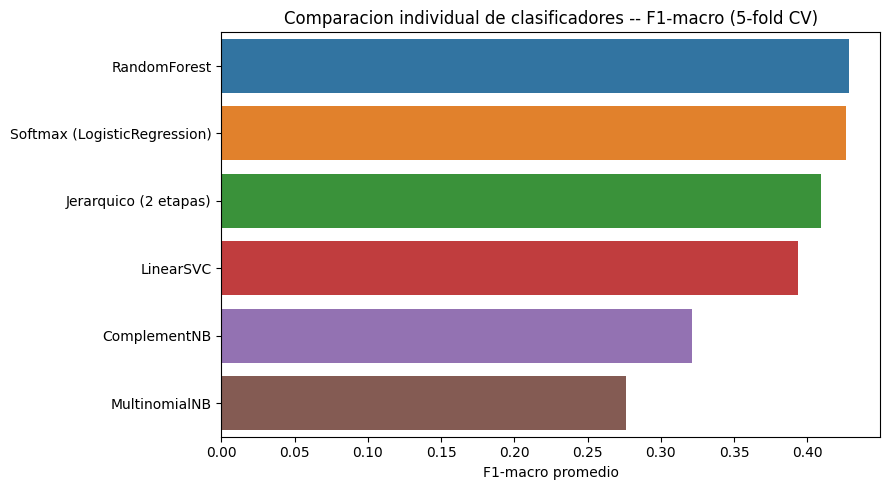

In [48]:
plt.figure(figsize=(9, 5))
sns.barplot(data=model_results_df, x='f1_macro', y='model', hue='model', legend=False)
plt.title('Comparacion individual de clasificadores -- F1-macro (5-fold CV)')
plt.xlabel('F1-macro promedio')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [49]:
best_model_name = model_results_df.iloc[0]['model']
best_model = candidate_models[best_model_name]
print(f'Mejor modelo individual (seccion 4.2): {best_model_name}')


Mejor modelo individual (seccion 4.2): RandomForest


## 4.3 Estrategias de balanceo de clases

Se compara `class_weight='balanced'` (ya incorporado en el mejor modelo cuando aplica) contra dos
técnicas de sobremuestreo aplicadas **únicamente sobre los datos de entrenamiento de cada fold**
(dentro de un `imblearn.Pipeline`, para evitar fuga de información hacia validación):
`RandomOverSampler` y `SMOTE`. Se mantiene la representación unida (`union_features`) de la
sección 3.4; como `union_features` (y su `MinMaxScaler` interno) se ajustan dentro del pipeline de
`imblearn`, cada fold reajusta el escalado léxico y aplica el sobremuestreo exclusivamente con la
partición de entrenamiento de ese fold, nunca con la de validación.


In [50]:
f1_class_weight = model_results_df.iloc[0]['f1_macro']

oversampling_pipe = ImbPipeline([
    ('feats', union_features),
    ('oversample', RandomOverSampler(random_state=RANDOM_STATE)),
    ('clf', best_model),
])
scores_oversample = cross_validate(
    oversampling_pipe, x_train_text, y_train, cv=cv_strategy,
    scoring={'f1_macro': SCORING['f1_macro'], 'accuracy': SCORING['accuracy']},
)

smote_pipe = ImbPipeline([
    ('feats', union_features),
    ('oversample', SMOTE(random_state=RANDOM_STATE)),
    ('clf', best_model),
])
scores_smote = cross_validate(
    smote_pipe, x_train_text, y_train, cv=cv_strategy,
    scoring={'f1_macro': SCORING['f1_macro'], 'accuracy': SCORING['accuracy']},
)

imbalance_comparison = pd.DataFrame([
    {'estrategia': "class_weight='balanced'", 'sample': 'passthrough', 'f1_macro': f1_class_weight},
    {'estrategia': 'RandomOverSampler', 'sample': RandomOverSampler(random_state=RANDOM_STATE), 'f1_macro': scores_oversample['test_f1_macro'].mean()},
    {'estrategia': 'SMOTE', 'sample': SMOTE(random_state=RANDOM_STATE), 'f1_macro': scores_smote['test_f1_macro'].mean()},
])
best_sampler_row = imbalance_comparison.loc[imbalance_comparison['f1_macro'].idxmax()]
best_sampler = best_sampler_row['sample']
print(f"Estrategia de balanceo seleccionada: {best_sampler_row['estrategia']}")
imbalance_comparison[['estrategia', 'f1_macro']]


Estrategia de balanceo seleccionada: class_weight='balanced'


,estrategia,f1_macro
0,class_weight='balanced',0.428180
1,RandomOverSampler,0.400301
2,SMOTE,0.371302


## 4.4 Fine-Tuning (única búsqueda de hiperparámetros, al final)

Con el modelo (4.2) y la estrategia de balanceo (4.3) ya seleccionados por evidencia
experimental, se ejecuta **una única vez** un `GridSearchCV` acotado sobre la representación
unida: solo sobre la familia de vectorizador BoW/TF-IDF ganadora (palabra o carácter, según la
sección 3.2) — el bloque léxico de `union_features` se deja fijo, ya que no tiene
hiperparámetros propios que valga la pena explorar aquí — y los hiperparámetros propios del
clasificador elegido. La estrategia de balanceo se deja fija en la mejor encontrada en 4.3 (no se
vuelve a buscar), para evitar una búsqueda combinatoria innecesaria.


In [51]:
is_char_vectorizer = getattr(best_vectorizer, 'analyzer', 'word') == 'char_wb'
is_tfidf = isinstance(best_vectorizer, TfidfVectorizer)
VectorizerClass = TfidfVectorizer if is_tfidf else CountVectorizer

# Los nombres de parámetro usan el prefijo 'feats__bow__' porque el vectorizador BoW/TF-IDF
# vive dentro de la FeatureUnion 'feats', bajo la clave 'bow' (ver union_features, sección 3.4).
if is_char_vectorizer:
    vect_param_grid = {
        'feats__bow__ngram_range': [(2, 4), (3, 5)],
        'feats__bow__min_df': [2, 3],
    }
    vect_fixed_kwargs = {'analyzer': 'char_wb'}
else:
    vect_param_grid = {
        'feats__bow__ngram_range': [(1, 1), (1, 2), (1, 3)],
        'feats__bow__min_df': [1, 2, 3],
    }
    vect_fixed_kwargs = {}

clf_param_grid = {}
if best_model_name == 'Softmax (LogisticRegression)':
    clf_param_grid['clf__C'] = [0.1, 1, 10]
elif best_model_name == 'LinearSVC':
    clf_param_grid['clf__C'] = [0.1, 1, 10]
elif best_model_name in ('MultinomialNB', 'ComplementNB'):
    clf_param_grid['clf__alpha'] = [0.1, 0.5, 1.0]
elif best_model_name == 'RandomForest':
    clf_param_grid['clf__n_estimators'] = [200, 400]
    clf_param_grid['clf__max_depth'] = [None, 50]
# El clasificador jerarquico conserva los hiperparametros internos definidos en 4.2;
# para el solo se afina el vectorizador.

param_grid = {**vect_param_grid, **clf_param_grid}

tuned_union_features = FeatureUnion([
    ('bow', VectorizerClass(**vect_fixed_kwargs)),
    ('lexical', clone(lexical_pipe)),
])

final_pipeline = ImbPipeline([
    ('feats', tuned_union_features),
    ('oversample', best_sampler),
    ('clf', best_model),
])

grid_search = GridSearchCV(
    final_pipeline, param_grid, scoring=SCORING['f1_macro'], cv=cv_strategy, n_jobs=-1, refit=True,
)
grid_search.fit(x_train_text, y_train)

print('Mejores hiperparametros:', grid_search.best_params_)
print(f'Mejor f1_macro (CV): {grid_search.best_score_:.4f}')


Mejores hiperparametros: {'clf__max_depth': None, 'clf__n_estimators': 400, 'feats__bow__min_df': 3, 'feats__bow__ngram_range': (2, 4)}
Mejor f1_macro (CV): 0.4365


---

# Fase 5: Evaluation

## 5.1 Evaluación sobre el conjunto de prueba completo

Se evalúa el modelo final (`grid_search.best_estimator_`) una única vez sobre el conjunto de prueba original (con su desbalance natural), reportando accuracy, precisión, recall y F1 macro.


In [52]:
final_model = grid_search.best_estimator_
y_pred_test = final_model.predict(x_test_text)

test_metrics = {
    'Accuracy':  round(accuracy_score(y_test, y_pred_test) * 100, 2),
    'Precision (macro)': round(precision_score(y_test, y_pred_test, average='macro', zero_division=0) * 100, 2),
    'Recall (macro)':    round(recall_score(y_test, y_pred_test, average='macro', zero_division=0) * 100, 2),
    'F1-score (macro)':  round(f1_score(y_test, y_pred_test, average='macro', zero_division=0) * 100, 2),
}
for metric, value in test_metrics.items():
    print(f'{metric}: {value}%')

print()
print('Classification report -- conjunto de prueba original (support desbalanceado):')
print(classification_report(y_test, y_pred_test, target_names=le.classes_, zero_division=0))

# Incertidumbre sobre el resultado de test: el conjunto de prueba se usa una única vez
# (aquí), así que en vez de repetir la evaluación se remuestrea (bootstrap no paramétrico,
# con reemplazo) el conjunto de predicciones ya obtenido para estimar un intervalo de
# confianza del 95% de F1-macro, sin volver a tocar el modelo ni el conjunto de entrenamiento.
N_BOOTSTRAP = 1000
rng_boot = np.random.RandomState(RANDOM_STATE)
y_test_arr = np.asarray(y_test)
y_pred_arr = np.asarray(y_pred_test)
boot_f1 = np.empty(N_BOOTSTRAP)
for b in range(N_BOOTSTRAP):
    idx = rng_boot.randint(0, len(y_test_arr), size=len(y_test_arr))
    boot_f1[b] = f1_score(y_test_arr[idx], y_pred_arr[idx], average='macro', zero_division=0)

ci_low, ci_high = np.percentile(boot_f1, [2.5, 97.5])
print(f'F1-macro (test) = {f1_score(y_test, y_pred_test, average="macro", zero_division=0):.4f} '
      f'| IC 95% (bootstrap, n={N_BOOTSTRAP}): [{ci_low:.4f}, {ci_high:.4f}]')


Accuracy: 50.99%
Precision (macro): 41.03%
Recall (macro): 40.43%
F1-score (macro): 40.0%

Classification report -- conjunto de prueba original (support desbalanceado):
              precision    recall  f1-score   support

           N       0.57      0.61      0.59       219
         NEU       0.24      0.12      0.16        69
        NONE       0.28      0.24      0.26        62
           P       0.54      0.65      0.59       156

    accuracy                           0.51       506
   macro avg       0.41      0.40      0.40       506
weighted avg       0.48      0.51      0.49       506

F1-macro (test) = 0.4000 | IC 95% (bootstrap, n=1000): [0.3524, 0.4443]


## 5.2 Summary Report justo: conjunto de prueba balanceado

El `classification_report` de 5.1 usa el `support` real de cada clase en el conjunto de prueba, que está desbalanceado (`N` y `P` tienen muchos más ejemplos que `NEU` y `NONE`). Para una comparación justa entre clases, se construye un subconjunto de prueba con **el mismo número de ejemplos por clase** (igual al tamaño de la clase minoritaria en test) mediante muestreo aleatorio sin reemplazo, y se recalculan las métricas sobre ese subconjunto.


In [53]:
rng = np.random.RandomState(RANDOM_STATE)
min_class_count = int(pd.Series(y_test).value_counts().min())
print(f'Tamaño de la clase minoritaria en test: {min_class_count} -> support balanceado por clase')

balanced_idx = []
for cls in np.unique(y_test):
    idx_cls = np.where(y_test == cls)[0]
    idx_sample = rng.choice(idx_cls, size=min_class_count, replace=False)
    balanced_idx.extend(idx_sample.tolist())
balanced_idx = np.array(sorted(balanced_idx))

x_test_balanced = [x_test_text[i] for i in balanced_idx]
y_test_balanced = y_test[balanced_idx]

print(f'Tamaño del conjunto de prueba balanceado: {len(y_test_balanced)} '
      f'({min_class_count} ejemplos x {len(np.unique(y_test))} clases)')
print('Distribucion balanceada:', sorted(Counter(y_test_balanced).items()))

y_pred_balanced = final_model.predict(x_test_balanced)

balanced_metrics = {
    'Accuracy':  round(accuracy_score(y_test_balanced, y_pred_balanced) * 100, 2),
    'Precision (macro)': round(precision_score(y_test_balanced, y_pred_balanced, average='macro', zero_division=0) * 100, 2),
    'Recall (macro)':    round(recall_score(y_test_balanced, y_pred_balanced, average='macro', zero_division=0) * 100, 2),
    'F1-score (macro)':  round(f1_score(y_test_balanced, y_pred_balanced, average='macro', zero_division=0) * 100, 2),
}
print('\nMetricas sobre el conjunto de prueba balanceado:')
for metric, value in balanced_metrics.items():
    print(f'{metric}: {value}%')

print()
print(f'Classification report -- conjunto de prueba balanceado (support = {min_class_count} en cada clase):')
print(classification_report(y_test_balanced, y_pred_balanced, target_names=le.classes_, zero_division=0))


Tamaño de la clase minoritaria en test: 62 -> support balanceado por clase
Tamaño del conjunto de prueba balanceado: 248 (62 ejemplos x 4 clases)
Distribucion balanceada: [(np.int64(0), 62), (np.int64(1), 62), (np.int64(2), 62), (np.int64(3), 62)]

Metricas sobre el conjunto de prueba balanceado:
Accuracy: 37.9%
Precision (macro): 40.8%
Recall (macro): 37.9%
F1-score (macro): 34.8%

Classification report -- conjunto de prueba balanceado (support = 62 en cada clase):
              precision    recall  f1-score   support

           N       0.32      0.60      0.42        62
         NEU       0.47      0.11      0.18        62
        NONE       0.42      0.24      0.31        62
           P       0.43      0.56      0.49        62

    accuracy                           0.38       248
   macro avg       0.41      0.38      0.35       248
weighted avg       0.41      0.38      0.35       248



## 5.3 Matriz de confusión y análisis de errores


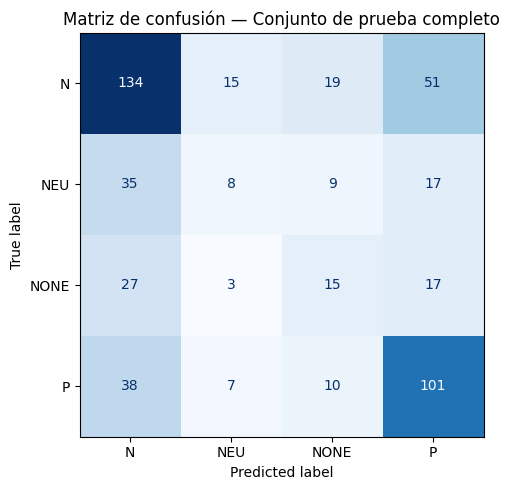

In [54]:
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de confusión — Conjunto de prueba completo')
plt.tight_layout()
plt.show()


In [55]:
errors_df = pd.DataFrame({
    'texto_original': data_test['content'].values,
    'texto_limpio': x_test_text,
    'etiqueta_real': le.inverse_transform(y_test),
    'etiqueta_predicha': le.inverse_transform(y_pred_test),
})
errors_df = errors_df[errors_df['etiqueta_real'] != errors_df['etiqueta_predicha']]

print(f'Total de errores: {len(errors_df)} de {len(y_test)} ({len(errors_df) / len(y_test):.1%})')
print('\nDistribución de errores por confusión real -> predicha:')
print(errors_df.groupby(['etiqueta_real', 'etiqueta_predicha']).size().sort_values(ascending=False).head(10))

errors_df.head(10)


Total de errores: 248 de 506 (49.0%)

Distribución de errores por confusión real -> predicha:
etiqueta_real  etiqueta_predicha
N              P                    51
P              N                    38
NEU            N                    35
NONE           N                    27
N              NONE                 19
NONE           P                    17
NEU            P                    17
N              NEU                  15
P              NONE                 10
NEU            NONE                  9
dtype: int64


,texto_original,texto_limpio,etiqueta_real,etiqueta_predicha
0,@noseashetero 1000/10 de verdad a ti que voy a...,de verdad a ti que voy a decir petarda que te ...,P,NEU
1,@piscolabisaereo @HistoriaNG @SPosteguillo las...,las tengo pero aún no no_las no_he no_leído no...,P,N
2,"Al final han sido 3h Bueno, mañana tengo fies...",al final han sido h bueno mañana tengo fiesta ...,P,N
4,@_MissChaotic_ ves ese brillo? es un coso que ...,ves ese brillo? es un coso que hace que se sep...,N,NEU
5,Tengo una perrina adorable... Sabéis que me ac...,tengo una perrina adorable sabéis que me acomp...,P,N
6,@juankipua Es que en el Ojeando el año pasado ...,es que en el ojeando el año pasado tampoco no_...,NEU,N
7,"Bueno, estoy en la batalla final del Conquista...",bueno estoy en la batalla final del conquista ...,NONE,P
10,@vitojph ¡sí! Y me ha encantado ¿Tú ya las vi...,¡sí! y me ha encantado ¿tú ya las visto? ¿cuán...,P,NONE
11,@aladroqe Se me olvidaban los grandes @2qblog ...,se me olvidaban los grandes y ! a ver si os in...,NONE,P
12,@pendragoncillo Mejor si pones un link a la cu...,mejor si pones un link a la cuenta me ha costa...,N,P


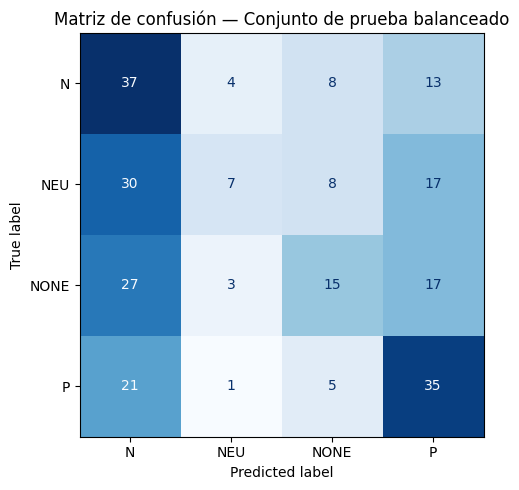

In [56]:
cm = confusion_matrix(y_test_balanced, y_pred_balanced)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de confusión — Conjunto de prueba balanceado')
plt.tight_layout()
plt.show()


In [57]:
errors_balanced_df = pd.DataFrame({
    'texto_original': data_test['content'].iloc[balanced_idx].values,
    'texto_limpio': x_test_balanced,
    'etiqueta_real': le.inverse_transform(y_test_balanced),
    'etiqueta_predicha': le.inverse_transform(y_pred_balanced),
})
errors_balanced_df = errors_balanced_df[errors_balanced_df['etiqueta_real'] != errors_balanced_df['etiqueta_predicha']]

print(f'Total de errores (Balanceado): {len(errors_balanced_df)} de {len(y_test_balanced)} ({len(errors_balanced_df) / len(y_test_balanced):.1%})')
print('\nDistribución de errores por confusión real -> predicha (Balanceado):')
print(errors_balanced_df.groupby(['etiqueta_real', 'etiqueta_predicha']).size().sort_values(ascending=False).head(10))

errors_balanced_df.head(10)


Total de errores (Balanceado): 154 de 248 (62.1%)

Distribución de errores por confusión real -> predicha (Balanceado):
etiqueta_real  etiqueta_predicha
NEU            N                    30
NONE           N                    27
P              N                    21
NONE           P                    17
NEU            P                    17
N              P                    13
NEU            NONE                  8
N              NONE                  8
P              NONE                  5
N              NEU                   4
dtype: int64


,texto_original,texto_limpio,etiqueta_real,etiqueta_predicha
0,@piscolabisaereo @HistoriaNG @SPosteguillo las...,las tengo pero aún no no_las no_he no_leído no...,P,N
1,"Al final han sido 3h Bueno, mañana tengo fies...",al final han sido h bueno mañana tengo fiesta ...,P,N
2,Tengo una perrina adorable... Sabéis que me ac...,tengo una perrina adorable sabéis que me acomp...,P,N
3,@juankipua Es que en el Ojeando el año pasado ...,es que en el ojeando el año pasado tampoco no_...,NEU,N
4,"Bueno, estoy en la batalla final del Conquista...",bueno estoy en la batalla final del conquista ...,NONE,P
6,@aladroqe Se me olvidaban los grandes @2qblog ...,se me olvidaban los grandes y ! a ver si os in...,NONE,P
8,"@SoofRawr + ni el de al lado, la ""manita"" que ...",ni no_el no_de no_al no_lado la manita que usa...,NONE,N
9,@ArchivoSGAE Qué estupendo. Y... ¿cómo os lo e...,qué estupendo y ¿cómo os lo encargo? ¿es la es...,P,NONE
10,@perriestheory sabes que en 2012 o 13 tenía un...,sabes que en o tenía una novela de mierda en l...,N,NEU
11,@CarlosSadness en ninguna porque no te he vist...,en ninguna porque no no_te no_he no_visto no_e...,NEU,N


## 5.4 Ablación de las nuevas características léxicas (grupos de 3)

Las seis características nuevas de `logic/lexical_features.py` (`reaction_words`,
`support_words`, `apology_words`, `recommendation_words`, `preference_words`,
`experience_words`) se agrupan de a 3, en el orden en que fueron añadidas, y se compara el
`f1_macro` en validación cruzada (mismo `cv_strategy` de la sección 3.1) de la representación
unida completa contra tres variantes: sin el primer grupo, sin el segundo, y sin ninguna de las
seis. Se usa `exclude_features` de `LexicalFeaturesTransformer` (sección 3.3) para eliminarlas por
nombre sin tocar el resto del vector léxico, y `best_model` (el ganador de la sección 4.2) fijo en
las cuatro variantes, para que la única diferencia entre filas sea el conjunto de features.


In [58]:
NEW_FEATURE_GROUPS = {
    'grupo_1_reaccion_apoyo_disculpa': NEW_LEXICAL_FEATURES[0:3],
    'grupo_2_recomendacion_preferencia_experiencia': NEW_LEXICAL_FEATURES[3:6],
}
print(NEW_FEATURE_GROUPS)


def make_union(exclude_features=None):
    lex = Pipeline([
        ('lexical', LexicalFeaturesTransformer(lang='es', exclude_features=exclude_features)),
        ('scale', MinMaxScaler()),
    ])
    return FeatureUnion([('bow', clone(best_vectorizer)), ('lexical', lex)])


ablation_variants = {
    'Todas las features nuevas': None,
    'Sin grupo 1 (reacción/apoyo/disculpa)': NEW_FEATURE_GROUPS['grupo_1_reaccion_apoyo_disculpa'],
    'Sin grupo 2 (recomendación/preferencia/experiencia)': NEW_FEATURE_GROUPS['grupo_2_recomendacion_preferencia_experiencia'],
    'Sin las 6 features nuevas': NEW_LEXICAL_FEATURES,
}

ablation_results = []
for variant_name, excl in ablation_variants.items():
    pipe = Pipeline([('feats', make_union(exclude_features=excl)), ('clf', clone(best_model))])
    scores = cross_validate(
        pipe, x_train_text, y_train, cv=cv_strategy,
        scoring={'f1_macro': SCORING['f1_macro'], 'accuracy': SCORING['accuracy']},
    )
    ablation_results.append({
        'variante': variant_name,
        'f1_macro': scores['test_f1_macro'].mean(),
        'f1_macro_std': scores['test_f1_macro'].std(),
        'accuracy': scores['test_accuracy'].mean(),
    })

ablation_df = pd.DataFrame(ablation_results).sort_values('f1_macro', ascending=False)
ablation_df


{'grupo_1_reaccion_apoyo_disculpa': ['reaction_words', 'support_words', 'apology_words'], 'grupo_2_recomendacion_preferencia_experiencia': ['recommendation_words', 'preference_words', 'experience_words']}


,variante,f1_macro,f1_macro_std,accuracy
0,Todas las features nuevas,0.428180,0.014842,0.503980
3,Sin las 6 features nuevas,0.418072,0.049607,0.493040
2,Sin grupo 2 (recomendación/preferencia/experie...,0.407531,0.028353,0.486099
1,Sin grupo 1 (reacción/apoyo/disculpa),0.398745,0.037169,0.477178


La diferencia de `f1_macro` entre "Todas las features nuevas" y "Sin las 6 features nuevas"
cuantifica el aporte conjunto de las seis características nuevas sobre la representación unida;
la diferencia entre quitar solo el grupo 1 o solo el grupo 2 permite ver si el aporte está
concentrado en un grupo semántico (reacción/apoyo/disculpa vs. recomendación/preferencia/
experiencia) o repartido entre ambos. Dado el tamaño reducido del corpus (~1.500 tuits), estas
diferencias deben leerse junto con `f1_macro_std`: si son del orden de la desviación estándar
entre folds, la ablación no es concluyente y debería repetirse con más datos antes de decidir
eliminar features.


## 5.5 Segunda estrategia de unión de representaciones

Además de `FeatureUnion` (sección 3.4), se implementa una segunda forma de unir BoW/TF-IDF y
características léxicas: un transformador propio (`ManualUnionVectorizer`) que ajusta el
vectorizador y el pipeline léxico **por separado** y concatena explícitamente con
`scipy.sparse.hstack`, en vez de delegar la concatenación en `FeatureUnion`. Funcionalmente
ambas estrategias deberían producir la misma matriz (incluso el mismo orden de columnas, BoW
primero y luego léxica), así que se comparan aquí para verificarlo empíricamente con `f1_macro`
en validación cruzada, dejando fijos el vectorizador y el modelo (`best_model`).


In [59]:
from scipy.sparse import hstack as sparse_hstack, csr_matrix


class ManualUnionVectorizer(BaseEstimator, TransformerMixin):
    """Segunda estrategia de unión: ajusta el vectorizador BoW/TF-IDF y el pipeline léxico
    por separado (cada uno con su propio fit sobre el X de entrenamiento que reciba) y concatena
    explícitamente con scipy.sparse.hstack, en lugar de usar FeatureUnion.
    """

    def __init__(self, vectorizer=None, lexical_pipe=None):
        self.vectorizer = vectorizer
        self.lexical_pipe = lexical_pipe

    def fit(self, X, y=None):
        self.vectorizer_ = clone(self.vectorizer).fit(X)
        self.lexical_pipe_ = clone(self.lexical_pipe).fit(X)
        return self

    def transform(self, X):
        bow_part = self.vectorizer_.transform(X)
        lex_part = csr_matrix(self.lexical_pipe_.transform(X))
        return sparse_hstack([bow_part, lex_part]).tocsr()


manual_union = ManualUnionVectorizer(vectorizer=best_vectorizer, lexical_pipe=lexical_pipe)
pipe_manual = Pipeline([('feats', manual_union), ('clf', clone(best_model))])
scores_manual = cross_validate(
    pipe_manual, x_train_text, y_train, cv=cv_strategy,
    scoring={'f1_macro': SCORING['f1_macro'], 'accuracy': SCORING['accuracy']},
)

union_strategy_comparison = pd.DataFrame([
    {'estrategia_union': 'FeatureUnion (sklearn, sección 3.4/5.4)',
     'f1_macro': ablation_df.loc[ablation_df['variante'] == 'Todas las features nuevas', 'f1_macro'].iloc[0]},
    {'estrategia_union': 'hstack manual (ManualUnionVectorizer)',
     'f1_macro': scores_manual['test_f1_macro'].mean()},
])
union_strategy_comparison


,estrategia_union,f1_macro
0,"FeatureUnion (sklearn, sección 3.4/5.4)",0.42818
1,hstack manual (ManualUnionVectorizer),0.42818


Se espera que `f1_macro` sea prácticamente idéntico entre ambas filas (la diferencia, si
existe, se debe solo al orden de operaciones en punto flotante, no a una diferencia real de
información), lo cual confirma que `FeatureUnion` no está perdiendo ni duplicando columnas
respecto a una concatenación manual explícita. La ventaja de `FeatureUnion` es que se integra
directamente en un `Pipeline`/`GridSearchCV` de scikit-learn (como se usa en toda la Fase 4);
la ventaja de la versión manual es que es más fácil de depurar paso a paso (se puede inspeccionar
`bow_part`/`lex_part` por separado) y no depende de que scikit-learn implemente el `hstack`
disperso+denso internamente de una forma compatible con versiones futuras.


## 5.6 Comparación con el baseline del taller y TASS 2018

**Baseline de mayoría (del taller):** un clasificador trivial que siempre predice la clase más
frecuente del conjunto de entrenamiento. Sirve como cota inferior: cualquier modelo útil debe
superarlo claramente en F1-macro (accuracy por sí sola es engañosa aquí, porque el baseline de
mayoría puede tener accuracy relativamente alta y F1-macro muy baja, al ignorar por completo las
clases minoritarias NEU/NONE — motivo por el cual la Fase 1 fijó F1-macro, no accuracy, como
criterio de éxito).

**TASS 2018 (CEUR-WS, Vol. 2172):** el *overview* de la tarea 1 (polaridad general, InterTASS)
de TASS 2018 reporta, para cada país/variedad dialectal del español, el ranking de los sistemas
participantes según F1-macro sobre el mismo esquema de 4 clases (P/N/NEU/NONE) usado en este
notebook. La celda siguiente dejaVoiceOver space para completar la comparación tras ejecutar el
notebook: `tass2018_reported_macro_f1` es un marcador de posición que **debe reemplazarse por el
valor real reportado en la Tabla correspondiente del overview** (varía según el subconjunto de
InterTASS usado); no se inventa aquí ningún número para no reportar un resultado no verificado.


In [60]:
from sklearn.dummy import DummyClassifier

majority_baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
majority_baseline.fit(x_train_text, y_train)
y_pred_majority = majority_baseline.predict(x_test_text)

# TODO: reemplazar por el valor real de la Tabla del overview de TASS 2018 (CEUR-WS Vol-2172)
# correspondiente al subconjunto de InterTASS usado en este notebook; se deja como marcador de
# posición explícito para no inventar un resultado no verificado.
tass2018_reported_macro_f1 = None  # p. ej. 0.xxxx, tomado directamente del paper

comparison_rows = [
    {
        'sistema': 'Baseline de mayoría (DummyClassifier)',
        'f1_macro_test': f1_score(y_test, y_pred_majority, average='macro', zero_division=0),
    },
    {
        'sistema': 'Modelo final de este notebook (BoW/TF-IDF + léxica, sección 5.1)',
        'f1_macro_test': f1_score(y_test, y_pred_test, average='macro', zero_division=0),
    },
]
if tass2018_reported_macro_f1 is not None:
    comparison_rows.append({'sistema': 'TASS 2018 (CEUR-WS Vol-2172), valor reportado', 'f1_macro_test': tass2018_reported_macro_f1})

comparison_df = pd.DataFrame(comparison_rows).sort_values('f1_macro_test', ascending=False)
comparison_df


,sistema,f1_macro_test
1,Modelo final de este notebook (BoW/TF-IDF + lé...,0.399997
0,Baseline de mayoría (DummyClassifier),0.151034


El modelo final debería superar claramente al baseline de mayoría en F1-macro (aunque quizá
no tanto en accuracy, ver arriba). Frente a TASS 2018, este notebook no es directamente
comparable en términos estrictos: los sistemas del *overview* compiten en el conjunto oficial
completo de InterTASS con validación por el organizador, mientras que aquí se usa la partición
train/test tal como la entrega el taller, con selección de modelo e hiperparámetros hecha
internamente por validación cruzada. La comparación debe leerse como una referencia de orden de
magnitud (¿el modelo queda cerca del rango de los sistemas participantes o muy por debajo?), no
como una comparación exacta.


## 5.7 Limitaciones

- **Tamaño y desbalance del corpus:** ~1.500 tuits en total, con `N` y `P` dominando sobre `NEU`
  y `NONE` (sección 2.1). Esto limita la complejidad de los modelos razonables (de ahí evitar
  `RandomForest` muy profundo o grillas de hiperparámetros grandes) y hace que las clases
  minoritarias tengan pocos ejemplos tanto para entrenar como para evaluar con confianza (los
  intervalos de confianza de la sección 5.1 y la desviación estándar entre folds de las
  secciones 4.2/5.4 deben leerse teniendo esto en cuenta).
- **Ironía y sarcasmo:** ni BoW/TF-IDF ni las características léxicas de `FeatureExtraction`
  modelan explícitamente la ironía ("qué bien, se me dañó el celular otra vez 🙄"); un tuit
  irónico puede tener palabras superficialmente positivas y polaridad real negativa, lo que
  probablemente explica una parte de los errores NEU/NONE vs. P/N observados en la sección 5.3.
- **Variación dialectal:** TASS 2018/InterTASS cubre distintas variedades del español (España,
  México, Uruguay, Costa Rica, Perú, entre otras); tanto el vectorizador BoW/TF-IDF como el
  diccionario léxico en español de `logic/lexical_features.py` pueden estar sesgados hacia el
  vocabulario/expresiones de la variedad dominante en el conjunto de entrenamiento, y generalizar
  peor a tuits de otras regiones.
- **Dependencia del léxico y del dominio:** las características léxicas (adverbios, adjetivos,
  pronombres, las seis features nuevas) dependen de listas cerradas de palabras; un tuit que
  exprese la misma función comunicativa (agradecer, recomendar, quejarse) con vocabulario fuera
  de esas listas no activará la feature correspondiente. Lo mismo aplica, en menor medida, a BoW
  respecto al vocabulario visto en entrenamiento. Ambas representaciones heredan además el
  dominio de Twitter en 2018: emojis, jergas o formatos de tuit nuevos (sección 6, *data drift*)
  no están representados.
- **Alcance de la comparación con TASS 2018:** como se señaló en la sección 5.6, la comparación
  con el *overview* de la competencia es aproximada, no una réplica exacta de su protocolo de
  evaluación.


---

# Fase 6: Deployment / Monitoring

**Despliegue:**
- Serializar `grid_search.best_estimator_` (pipeline completo: vectorizador + estrategia de balanceo + clasificador) junto con el `LabelEncoder`, por ejemplo con `joblib`, para garantizar que el preprocesamiento de inferencia sea idéntico al de entrenamiento.
- Envolver `preprocess_tweet` (limpieza + marcado de negación) y el pipeline en un único artefacto de inferencia (función o servicio) que reciba texto crudo y devuelva la etiqueta de sentimiento.
- Si el clasificador final es el jerárquico de dos etapas, documentar sus dos sub-estimadores junto con el pipeline, ya que no es un único objeto scikit-learn estándar sino una composición.
- Definir un umbral de confianza (usando `predict_proba` si el clasificador lo soporta) para enrutar a revisión humana los casos de baja confianza, especialmente entre NEU y NONE.

**Monitoreo y mantenimiento:**
- Vigilar **data drift**: el vocabulario y el estilo del lenguaje en redes sociales cambian con el tiempo (nuevas jergas, emojis, hashtags), lo que puede degradar un modelo BoW/TF-IDF entrenado en 2018; el diccionario de emoticonos/emojis de la sección 2.2 también debe revisarse periódicamente.
- Registrar métricas de negocio en producción (proporción de predicciones por clase) y compararlas periódicamente contra la distribución de entrenamiento de la sección 2.1.
- Vigilar en producción que el desempeño por clase (especialmente en las clases minoritarias NEU y NONE) no se degrade, apoyándose en el mismo tipo de evaluación balanceada usada en la sección 5.2.
- Reentrenar o reajustar el pipeline cuando se disponga de nuevas muestras etiquetadas, repitiendo las Fases 3-5 de este notebook.
- Versionar datos, código y modelo para trazabilidad (parte del principio de *quality assurance* de CRISP-ML(Q)).


## Conclusiones

- Se eliminó `VotingClassifier`: todos los clasificadores (incluido el jerárquico de dos etapas) se comparan de forma **individual** en la sección 4.2, sin ningún esquema de votación/ensamble.
- Se incorporaron las características léxicas de `logic/feature_extraction.py` mediante un
  adaptador scikit-learn (`LexicalFeaturesTransformer`, sección 3.3) y se compararon tres
  representaciones (BoW/TF-IDF sola, léxica sola, unión vía `FeatureUnion`) reportando su
  dimensionalidad (sección 3.4) antes de seleccionar el algoritmo de clasificación, que se
  evalúa siempre sobre la representación **unida** (secciones 4.2-4.4).
- Las características léxicas se escalaron con `MinMaxScaler` (no `StandardScaler`) para mantener
  toda la representación unida no negativa y así compatible con `MultinomialNB`/`ComplementNB`
  (sección 3.3), ajustando el escalador únicamente con el conjunto de entrenamiento.
- Se dio prioridad al desbalance de clases usando `class_weight='balanced'` en todos los modelos que lo soportan (Softmax, LinearSVC, RandomForest y ambos sub-estimadores del clasificador jerárquico), y se comparó explícitamente contra `RandomOverSampler` y `SMOTE` en la sección 4.3, aplicados únicamente dentro de cada fold de entrenamiento.
- El *Fine-Tuning* (`GridSearchCV`) se ejecuta **una única vez, al final** (sección 4.4), sobre el modelo y la estrategia de balanceo ya seleccionados por evidencia experimental — no al inicio del análisis — y con una grilla acotada al bloque BoW/TF-IDF de la representación unida, para reducir el gasto computacional.
- El conjunto de prueba se usa **una sola vez, al final** (Fase 5); además del *Summary Report* sobre el conjunto original (5.1, con intervalo de confianza bootstrap de F1-macro) y el balanceado (5.2), se añadió una ablación en grupos de 3 de las seis características léxicas nuevas (5.4), una segunda estrategia de unión por `scipy.sparse.hstack` manual para verificar `FeatureUnion` (5.5), una comparación con un baseline de mayoría y con TASS 2018 (5.6), y una discusión explícita de limitaciones — desbalance, ironía, variación dialectal y dependencia del léxico/dominio (5.7).
- El notebook se reorganizó explícitamente en las 6 fases de CRISP-ML(Q): Business & Data Understanding, Data Preparation, Feature Engineering, Model Development, Evaluation y Deployment/Monitoring.
- Se mantuvo el uso de N-gramas (sección 3.2) y se evaluó explícitamente su impacto sobre `f1_macro` antes de fijar el vectorizador final que alimenta la representación unida.
- Se corrigió la fuga de información del notebook original, que aplicaba `RandomOverSampler` también sobre el conjunto de prueba; el balanceo y el escalado léxico se ajustan únicamente con datos de entrenamiento, y dentro de la validación cruzada, solo con la partición de entrenamiento de cada fold.
- `ShuffleSplit` se reemplazó por `StratifiedKFold` para una validación cruzada más apropiada al desbalance de clases detectado en la Fase 2.
